# **OBJECTIVE :**
## >>> <b>Predict the next purchase based on the historical ones - For recommandation usage<b>
# **`Business Case & Hypothesis`**
# **`With Databricks & PySpark & NeuMF & Gensim Word2Vec`**
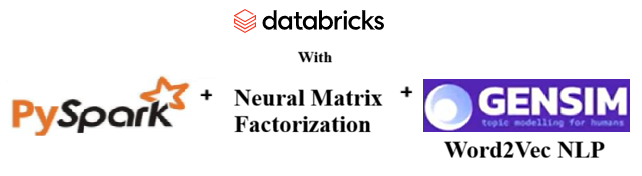





# <b><span style="color:blue;">1. CONTEXT DESCRIPTION<b>

# >>> <b>Goal:<b>
## <b>Analyze impulsive or related purchase based on a previous purchased item :<b>
### For each transaction contening the article A, what is the probability then to buy the article B, C, D ...

## <b>Predict a second purchase during the 'term windows':<b>
### A) 0 - 1 day
### B) 0 - 3 days
### C) 0 - 7 days

### Do to it, I have created a <b>Deep Learning Algorithm Neural Matrix Factorization.<b>
### NeuMF : It's an algorithm used by big companies for recommandation systeme (films, books etc..). It combine GMF to discover simple linear relationship and MLP with AI to discover complex patterns.

### Then I will integrate the prediction to an interactive dashboard (using Power BI) for the best UI / UX experience.

## >>>> **For this tasks, there is 2 points I toke into account:**
### **A) Data**
#### My objective was to discover a potential second purchase based on a first one. So I decided to **focus on the most recent data** so I filtered the dataset on the **last six month period**


### **B) Technologies**
#### > Concerning the plateform, I used databricks combined with spark.
#### > For the model, I used Word2Vec (to discover relationship on the merchant categories) and NeuMF which is e pwoerful tool to discover complex patterns.


## <b>Source : Financial Transactions Dataset (www.Kaggle.com)<b>


#### Overview : This comprehensive financial dataset combines transaction records, customer information, and card data from a banking institution, spanning across the 2010s decade.

### Dataset Information

#### <b><u>1. Transaction Data<b><u>

##### * Detailed transaction records including amounts, timestamps, and merchant details
##### * Covers transactions throughout the 2010s
##### * Features transaction types, amounts, and merchant information
##### * Perfect for analyzing spending patterns and building fraud detection models

| Variable      | Description                                                                                                 |
| ------------- | ----------------------------------------------------------------------------------------------------------- |
| id            | ID number of the transaction                                                                                |
| date          | Transction's date                                                                                           |
| client_id     | Client id number                                                                                            |
| card_id       | Card id number                                                                                              |
| amount        | Amount of the transaction                                                                                   |
| use_chip      | Transaction methodology                                                                                     |
| merchant_id   | ID munber of the merchant                                                                                   |
| merchant_city | City of the merchant                                                                                        |
| merchant_state| State of the merchant                                                                                       |
| zip           | Zip code of the merchant                                                                                    |
| mcc           | ID number indicating the category goods or services concerned by the transation                             |
| errors        | Transaction Error                                                                                           |




#### <b><u>2. User Data<b><u>

##### * Demographic information about customers
##### * Account-related details
##### * Enables customer segmentation and personalized analysis

| Variable      | Description                                                                                                 |
| ------------- | ----------------------------------------------------------------------------------------------------------- |
| id            | ID number of the user                                                                                       |                         
| current_age   | Age of the User                                                                                             |
| retirement_age| Age of retirement (done or planned)                                                                         |
| birth_year    | Year of birth                                                                                               |
| birth_month   | Month of bitrh                                                                                              |
| Gender        | Gendrer                                                                                                     |
| Adress        | Adress                                                                                                      |
| Latitude      | Latitude of the Adress                                                                                      |
| Longitude     | Longitude of the Adress                                                                                     |
| per_capita_income| Income per number of people                                                                              |
| yearly_income | Yearly Income of the User                                                                                   |
| total_debt    | TOTAL amount of debt                                                                                        |
| credit_score  | Credit Score                                                                                                |
| num_credit_cards    | Number of credit cards                                                                                |


#### <b><u>3. Merchant Category Codes<b><u>

##### * Standard classification codes for business types
##### * Enables transaction categorization and spending analysis
##### * Industry-standard MCC codes with descriptions

| Variable      | Description                                                                                                 |
| ------------- | ----------------------------------------------------------------------------------------------------------- |
| id            | ID number of the category                                                                                   |                         
| description   | Categorie description                                                                                       |


# <b><span style="color:blue;">2. SETUP<b>

#### <b><u>1. Horizon and Prediction Setup<b><u>

##### <b>Concept : Definition of the 'window time'</b>
##### In order to have a useful algorithm, <u>it must know what it have to predict:</u>
#### h1 => for next 1 day prediction
#### h3 => for next 3 days prediction
#### h7 => for next 7 days prediction

<b><i>This is useful to adapt the marketing strategy.</i></b>

In [ ]:
#!pip install tensorflow
#!pip install gensim

In [ ]:
dbutils.library.restartPython()

In [ ]:
# --- CONFIGURATION MODE ---
# h1 for prediction horizon 1 day | h3 for prediction horizon 3 days | h7 for prediction horizon 7 days
TARGET_MODE = "h1"

# Parameters definition
if TARGET_MODE == "h1":
    delta_target = 1
    test_interval = 14 # test based on the interval of 14 days
elif TARGET_MODE == "h3":
    delta_target = 3
    test_interval = 14 # test based on the interval of 14 days
else: # h7
    delta_target = 7
    test_interval = 28 # test based on the interval of 28 days

#### <b><u>2. Libraries Setup<b><u>

In [ ]:
# =========================
# 0. Imports Libraries (Spark + util)
# =========================

# Util Libraries
import pandas as pd
from functools import reduce

# Spark Libraries
import pyspark.sql.functions as F
from functools import reduce
from pyspark.sql import SparkSession
from pyspark.sql.window import Window
from pyspark.sql.types import ArrayType, StringType, IntegerType, StructType, StructField, DoubleType

# Word2Vec (Gensim)
from gensim.models import Word2Vec as GensimW2V

# Deep Learning Libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Warnings
import warnings
warnings.filterwarnings("ignore")


/local_disk0/.ephemeral_nfs/envs/pythonEnv-87cfb61b-8e7d-4806-9a4b-34977c2046bc/lib/python3.12/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


# <b><span style="color:blue;">3. CLEANING & STANDARDIZATION<b>

#### <b><u>1. Spark Session Creation<b><u>

In [ ]:
# =========================
# 1. Spark session
# =========================
spark = SparkSession.builder.appName("NCF_Prepare").getOrCreate()

# Table List
transactions_csv = "workspace.portfolio.transactions_data"
users_csv = "workspace.portfolio.users_data"
mcc_json = "workspace.portfolio.mcc_codes"


# Load to Spark
td = spark.table("workspace.portfolio.transactions_data")
ud = spark.table("workspace.portfolio.users_data")
mcc = spark.table("workspace.portfolio.mcc_codes")

#### <b><u>2. Data Wrangling<b><u>

##### <b>Concept : Clean, filter, join data</b>
##### To prepare the dataframe with clean and useful data / format for this business case.</u>


In [ ]:
# =========================
# 2. Filtering data
# =========================

# Period Filter (>= 2019-08-01) -- free versionn could not manage the entire volume of data - I chose a compromize with the last year data
td = td.withColumn("date", F.to_date("date"))
td = td.filter(F.col("date") >= F.lit("2019-08-01"))

# Clean Amount Column
td = td.withColumnRenamed("amount", "amount_raw")
td = td.withColumn("amount_raw", F.regexp_replace("amount_raw", "\\$", ""))
td = td.withColumn("amount", F.col("amount_raw").cast("double")).drop("amount_raw")

# Filter amount > 0 - to exlude negative amounts
td = td.filter(F.col("amount") > 0)

In [ ]:
# =========================
# 3. Mapping Category Creation
# =========================

# Creation of a mapping dictionary for the mcc_code
mapping_categories = {
'5812' : 'Restaurants and Dining Out',
'5541' : 'Automotive and Transportation',
'7996' : 'Entertainment and Leisure',
'5411' : 'Groceries',
'4784' : 'Automotive and Transportation',
'4900' : 'Utilities',
'5942' : 'Media, Books and Digital Entertainment',
'5814' : 'Restaurants and Dining Out',
'4829' : 'Financial Services',
'5311' : 'Clothing and General Shopping',
'5211' : 'Home and Hardware',
'5310' : 'Clothing and General Shopping',
'3780' : 'IT and Communication Services',
'5499' : 'Groceries',
'4121' : 'Automotive and Transportation',
'5300' : 'Groceries',
'5719' : 'Home, Furniture and Decor',
'7832' : 'Entertainment and Leisure',
'5813' : 'Restaurants and Dining Out',
'4814' : 'IT and Communication Services',
'5661' : 'Clothing and General Shopping',
'5977' : 'Personal Care and Beauty',
'8099' : 'Health and Wellness',
'7538' : 'Automotive and Transportation',
'5912' : 'Health and Wellness',
'4111' : 'Automotive and Transportation',
'5815' : 'Media, Books and Digital Entertainment',
'8021' : 'Health and Wellness',
'5921' : 'Groceries',
'5655' : 'Clothing and General Shopping',
'7230' : 'Personal Care and Beauty',
'3390' : 'Industrial Materials and Services',
'7922' : 'Entertainment and Leisure',
'3722' : 'Automotive and Transportation',
'5651' : 'Clothing and General Shopping',
'4899' : 'IT and Communication Services',
'5251' : 'Home and Hardware',
'7995' : 'Entertainment and Leisure',
'3596' : 'Industrial Materials and Services',
'3730' : 'Industrial Materials and Services',
'9402' : 'Postal Services',
'7801' : 'Entertainment and Leisure',
'5970' : 'Creative Hobbies and Supplies',
'5932' : 'Home, Furniture and Decor',
'5621' : 'Clothing and General Shopping',
'7349' : 'Home Services',
'4722' : 'Travel and Transportation',
'5193' : 'Home and Hardware',
'3775' : 'Freight Transportation',
'3684' : 'Electronics and Technology',
'5045' : 'Electronics and Technology',
'3504' : 'Home and Hardware',
'7011' : 'Travel and Transportation',
'8041' : 'Health and Wellness',
'4214' : 'Freight Transportation',
'6300' : 'Financial Services',
'8011' : 'Health and Wellness',
'3509' : 'Industrial Materials and Services',
'7210' : 'Home Services',
'5192' : 'Media, Books and Digital Entertainment',
'7542' : 'Automotive and Transportation',
'3640' : 'Home and Hardware',
'7393' : 'Professional Services',
'8111' : 'Professional Services',
'3771' : 'Automotive and Transportation',
'5732' : 'Electronics and Technology',
'5094' : 'Jewelry and Luxury Goods',
'5712' : 'Home, Furniture and Decor',
'5816' : 'Media, Books and Digital Entertainment',
'7802' : 'Entertainment and Leisure',
'3389' : 'Industrial Materials and Services',
'8043' : 'Health and Wellness',
'3393' : 'Industrial Materials and Services',
'3174' : 'Home, Furniture and Decor',
'3001' : 'Industrial Materials and Services',
'3395' : 'Industrial Materials and Services',
'3058' : 'Industrial Materials and Services',
'8049' : 'Health and Wellness',
'3387' : 'Industrial Materials and Services',
'4112' : 'Automotive and Transportation',
'3405' : 'Industrial Materials and Services',
'5261' : 'Home and Hardware',
'3144' : 'Home, Furniture and Decor',
'3132' : 'Clothing and General Shopping',
'3359' : 'Industrial Materials and Services',
'8931' : 'Professional Services',
'8062' : 'Health and Wellness',
'7276' : 'Professional Services',
'4131' : 'Automotive and Transportation',
'3260' : 'Creative Hobbies and Supplies',
'3256' : 'Industrial Materials and Services',
'3006' : 'Industrial Materials and Services',
'7531' : 'Automotive and Transportation',
'1711' : 'Home Services',
'5947' : 'Clothing and General Shopping',
'3007' : 'Industrial Materials and Services',
'4511' : 'Travel and Transportation',
'3075' : 'Industrial Materials and Services',
'3066' : 'Industrial Materials and Services',
'3005' : 'Industrial Materials and Services',
'4411' : 'Travel and Transportation',
'3000' : 'Industrial Materials and Services',
'5533' : 'Automotive and Transportation',
'3008' : 'Industrial Materials and Services',
'7549' : 'Automotive and Transportation',
'5941' : 'Clothing and General Shopping',
'5722' : 'Home, Furniture and Decor',
'3009' : 'Industrial Materials and Services',
'5733' : 'Media, Books and Digital Entertainment'
}


In [ ]:
# =========================
# 4. Joining tables transaction with Mapping categories
# =========================

#  Normalization of the column mcc in transations_data
td = td.withColumn("mcc", F.trim(F.col("mcc").cast("string")))

# convert mapping categories dictionnary to spark DataFrame
mapping_spark_categories = spark.createDataFrame(
    [(k, v) for k, v in mapping_categories.items()],
    ["mcc_code", "category"]
)

# Normalization of the column mcc_code in mapping categories
mapping_spark_categories = mapping_spark_categories.withColumn("mcc_code", F.trim(F.col("mcc_code").cast("string")))

# Joining tables
td = td.join(
    F.broadcast(mapping_spark_categories),
    td["mcc"] == mapping_spark_categories["mcc_code"],
    how="left"
).drop(mapping_spark_categories["mcc_code"])

# Mapping verification
td = td.withColumn("category", F.when(F.col("category").isNull(), F.lit("UNKNOWN")).otherwise(F.col("category")))

# Check for unknown MCC
unknown_count = td.filter(F.col("category") == "UNKNOWN").count()
total_count = td.count()
print(f"Unknown MCC after join: {unknown_count} rows ({unknown_count/total_count:.2%})")

Unknown MCC after join: 0 rows (0.00%)


In [ ]:
# =========================
# 5. Joining tables transaction with Users
# =========================

#  Normalization of the column mcc in transations_data
td = td.withColumn("client_id", F.trim(F.col("client_id").cast("string")))

# Normalization of the column 'id' in mapping categories
mapping_spark_users = ud.withColumn("id", F.trim(F.col("id").cast("string")))

# Joining tables
td = td.join(
    F.broadcast(mapping_spark_users),
    td["client_id"] == mapping_spark_users["id"],
    how="left"
).drop(mapping_spark_users["id"])

# Mapping verification
td = td.withColumn("client_id", F.when(F.col("client_id").isNull(), F.lit("UNKNOWN")).otherwise(F.col("client_id")))

# Check for unknown MCC
unknown_count = td.filter(F.col("client_id") == "UNKNOWN").count()
total_count = td.count()
print(f"Unknown client_id after join: {unknown_count} rows ({unknown_count/total_count:.2%})")


Unknown client_id after join: 0 rows (0.00%)


In [ ]:
#=========================
# 6. BUILD TRANSACTIONS_JOINED TABLE - CLEAN TABLE READY FOR EVENTS ENRICHED
#=========================

# PARAMETERS
TRANSACTIONS_JOINED_TABLE = "workspace.portfolio.transactions_joined"

# Filtering Table Amount > 0 & Client_id notnull & Merchant_id notnull & Date notnull
df = td.filter(
    (F.col("amount") > 0) &
    (F.col("client_id").isNotNull()) &
    (F.col("merchant_id").isNotNull()) &
    (F.col("date").isNotNull())
)

# Date format to timestamp
df = df.withColumn(
    "event_timestamp",
    F.col("date").cast("timestamp")
)

# Select useful columns only
df = df.select(
    "id",
    "event_timestamp",
    "client_id",
    "merchant_id",
    "amount",
    "category",
    "merchant_city",
    "merchant_state",
    "mcc"
)

# Rename for clarity - item_id
df = df.withColumnRenamed("merchant_id", "item_id")

# Type casting
df = (
    df
    .withColumn("amount", F.col("amount").cast("double"))
    .withColumn("event_timestamp", F.col("event_timestamp").cast("timestamp"))
)

# Persist transactions_joined
spark.sql(f"DROP TABLE IF EXISTS {TRANSACTIONS_JOINED_TABLE}")

df.write.mode("overwrite").saveAsTable(TRANSACTIONS_JOINED_TABLE)

print(f"transactions_joined created: {TRANSACTIONS_JOINED_TABLE}")
print(f"Rows: {df.count()}")
print(f"Users: {df.select('client_id').distinct().count()}")
print(f"Items: {df.select('item_id').distinct().count()}")


transactions_joined created: workspace.portfolio.transactions_joined
Rows: 333517
Users: 1206
Items: 17241


# <b><span style="color:blue;">3. FEATURE ENGINEERING<b>

##### <b>Concept : Add context to each purchase</b>
##### Because a 10 dollars purchase on monday does not have the same signification than a 100 dollars purchase on saturday
##### More information will be given to the algorithm, more context will the algorithm learn and then the AI will understand the consumers life style


In [ ]:
#=========================
# 7. BUILD EVENTS_ENRICHED
#=========================

# PARAMETERS
SOURCE_TABLE = "workspace.portfolio.transactions_joined"
EVENTS_ENRICHED_TABLE = "workspace.portfolio.events_enriched"

# Load transactions_joined
df = spark.table(SOURCE_TABLE)

# Standardize entity names
df = (
    df
    .withColumnRenamed("client_id", "user_id")
)

# Interaction weight (simple & extensible)
df = df.withColumn(
    "interaction_weight",
    F.when(F.col("amount") < 20, F.lit(1.0))
     .when(F.col("amount") < 100, F.lit(2.0))
     .otherwise(F.lit(3.0))
)

# Amount bucket (business context)
df = df.withColumn(
    "amount_bucket",
    F.when(F.col("amount") < 20, F.lit("LOW"))
     .when(F.col("amount") < 100, F.lit("MID"))
     .otherwise(F.lit("HIGH"))
)

# Temporal context features
df = df.withColumn(
    "weekday",
    F.dayofweek("event_timestamp")  # 1=Sunday ... 7=Saturday
)

df = df.withColumn(
    "is_weekend",
    F.col("weekday").isin([1, 7])
)

# Defensive sanity filter
df = df.filter(
    (F.col("user_id").isNotNull()) &
    (F.col("item_id").isNotNull()) &
    (F.col("event_timestamp").isNotNull())
)

# Select final column order
df = df.select(
    "user_id",
    "item_id",
    "event_timestamp",
    "amount",
    "interaction_weight",
    "amount_bucket",
    "weekday",
    "is_weekend",
    "category",
    "mcc",
    "merchant_city",
    "merchant_state"
)

# Persist events_enriched
spark.sql(f"DROP TABLE IF EXISTS {EVENTS_ENRICHED_TABLE}")

df.write.mode("overwrite").saveAsTable(EVENTS_ENRICHED_TABLE)

print(f"events_enriched created: {EVENTS_ENRICHED_TABLE}")
print(f"Rows: {df.count()}")
print(f"Users: {df.select('user_id').distinct().count()}")
print(f"Items: {df.select('item_id').distinct().count()}")


events_enriched created: workspace.portfolio.events_enriched
Rows: 333517
Users: 1206
Items: 17241


# <b><span style="color:blue;">4. INTERACTIONS CLEANING<b>

##### <b>Concept : To focus on a strong signal</b>
##### To predict the future, a solid historic is needed. That's why I focus on consummers with at least more than 10 interactions

In [ ]:
#=========================
# 8. BUILD INTERACTIONS_CLEAN
#=========================

# PARAMETERS
SOURCE_TABLE = "workspace.portfolio.events_enriched"
INTERACTIONS_CLEAN_TABLE = "workspace.portfolio.interactions_clean"

MAX_MONTHS_HISTORY = 3
MIN_USER_INTERACTIONS = 10
MIN_ITEM_INTERACTIONS = 5

# Load events_enriched
df = spark.table(SOURCE_TABLE)

# Defensive temporal filter (3 months)
max_ts = spark.table(SOURCE_TABLE).agg(F.max("event_timestamp")).collect()[0][0]

df = df.filter(
    F.col("event_timestamp") >= F.add_months(F.lit(max_ts), -12)
)

# Deduplicate user–item–day and Keep strongest interaction per day
df = df.withColumn(
    "event_date",
    F.to_date("event_timestamp")
)

w_dedupe = Window.partitionBy(
    "user_id", "item_id", "event_date"
).orderBy(
    F.desc("interaction_weight"), F.asc("event_timestamp")
)

df = (
    df
    .withColumn("rn", F.row_number().over(w_dedupe))
    .filter(F.col("rn") == 1)
    .drop("rn", "event_date")
)

# Filter items (≥ 5 interactions)
item_counts = (
    df
    .groupBy("item_id")
    .count()
    .filter(F.col("count") >= MIN_ITEM_INTERACTIONS)
    .select("item_id")
)

df = df.join(item_counts, on="item_id", how="inner")

# Filter users (≥ 10 interactions)
user_counts = (
    df
    .groupBy("user_id")
    .count()
    .filter(F.col("count") >= MIN_USER_INTERACTIONS)
    .select("user_id")
)

df = df.join(user_counts, on="user_id", how="inner")

#  Add event_rank
w_rank = Window.partitionBy("user_id").orderBy("event_timestamp")

df = df.withColumn(
    "event_rank",
    F.row_number().over(w_rank)
)

# Select final columns
df = df.select(
    "user_id",
    "item_id",
    "event_timestamp",
    "event_rank",
    "interaction_weight",
    "amount_bucket",
    "weekday",
    "is_weekend",
    "category",
    "mcc"
)

# Persist interactions_clean
spark.sql(f"DROP TABLE IF EXISTS {INTERACTIONS_CLEAN_TABLE}")

df.write.mode("overwrite").saveAsTable(INTERACTIONS_CLEAN_TABLE)

print(f"interactions_clean created: {INTERACTIONS_CLEAN_TABLE}")
print(f"Rows: {df.count()}")
print(f"Users: {df.select('user_id').distinct().count()}")
print(f"Items: {df.select('item_id').distinct().count()}")



interactions_clean created: workspace.portfolio.interactions_clean
Rows: 262383
Users: 1206
Items: 5287


# <b><span style="color:blue;">5. INTERACTIONS PATTERNS<b>

##### <b>Concept : Understand the link between an item A and an item B</b>
##### To create a self-join link between items by defining labels:
##### h1 : does the next purchase was done the next day ?
##### h3 : does the next purchase was done the next 3 days ?
##### h7 : does the next purchase was done the next 7 days ?

##### It prepare as well the business scenarios - to split the dataframe in 3 cases

In [ ]:
#=========================
# 9. TEMPORAL PAIRS GENERATION
#=========================

# Self Join pairs per user
interactions = spark.table("workspace.portfolio.interactions_clean")

pairs = (
    interactions.alias("a")
    .join(
        interactions.alias("b"),
        on="user_id"
    )
    .where(F.col("b.event_timestamp") > F.col("a.event_timestamp"))
    .withColumn(
        "delta_days",
        F.datediff(
            F.col("b.event_timestamp"),
            F.col("a.event_timestamp")
        )
    )
    .filter(F.col("delta_days") <= 7)
)

# Labels creation
labeled_pairs = (
    pairs
    .select(
        F.col("a.user_id").alias("user_id"),
        F.col("a.item_id").alias("item_A_id"),
        F.col("b.item_id").alias("item_B_id"),
        F.col("delta_days"),
        F.when(F.col("delta_days") <= 1, 1).otherwise(0).alias("label_h1"),
        F.when(F.col("delta_days") <= 3, 1).otherwise(0).alias("label_h3"),
        F.when(F.col("delta_days") <= 7, 1).otherwise(0).alias("label_h7"),
    )
)

# Delete old data
spark.sql("DROP TABLE IF EXISTS workspace.portfolio.train_h1_pairs")
spark.sql("DROP TABLE IF EXISTS workspace.portfolio.train_h3_pairs")
spark.sql("DROP TABLE IF EXISTS workspace.portfolio.train_h7_pairs")

# Labeled tables creation
labeled_pairs.select(
    "user_id", "item_A_id", "item_B_id", "label_h1"
).filter("label_h1 = 1") \
 .write.mode("overwrite") \
 .option("mergeSchema", "true") \
 .saveAsTable("workspace.portfolio.train_h1_pairs")

labeled_pairs.select(
    "user_id", "item_A_id", "item_B_id", "label_h3"
).filter("label_h3 = 1") \
 .write.mode("overwrite") \
 .option("mergeSchema", "true") \
 .saveAsTable("workspace.portfolio.train_h3_pairs")

labeled_pairs.select(
    "user_id", "item_A_id", "item_B_id", "label_h7"
).filter("label_h7 = 1") \
 .write.mode("overwrite") \
 .option("mergeSchema", "true") \
 .saveAsTable("workspace.portfolio.train_h7_pairs")

In [ ]:
#=========================
# 10. TEMPORAL WINDOWS SETUP
#=========================

# Interval windows creation
interactions = spark.table("workspace.portfolio.interactions_clean")

max_ts = interactions.agg(F.max("event_timestamp")).collect()[0][0]
cutoff_ts = F.expr(f"timestamp('{max_ts}') - interval {test_interval} days")

table_test_name = f"workspace.portfolio.test_{TARGET_MODE}_pairs"

# Filter on the test interval
test_pairs = (
    interactions.alias("a")
    .join(interactions.alias("b"), on="user_id")
    .where(F.col("b.event_timestamp") > F.col("a.event_timestamp"))
    .withColumn("delta_days", F.datediff(F.col("b.event_timestamp"), F.col("a.event_timestamp")))
    .filter(
        (F.col("delta_days") <= delta_target) &
        (F.col("a.event_timestamp") >= cutoff_ts)
    )
    .select(
        F.col("a.user_id").alias("user_id"),
        F.col("a.item_id").alias("item_A_id"),
        F.col("b.item_id").alias("item_B_id")
    )
    .dropDuplicates()
)

spark.sql(f"DROP TABLE IF EXISTS {table_test_name}")

test_pairs.write.mode("overwrite").saveAsTable(table_test_name)

print(f"Test pairs created : {table_test_name}")
print(f"Nb of rows : {test_pairs.count()}")

# Get all unique IDs of items in our dataset
all_items = (
    spark.table("workspace.portfolio.interactions_clean").select("item_id")
    .union(spark.table("workspace.portfolio.train_h7_pairs").select(F.col("item_A_id").alias("item_id")))
    .union(spark.table("workspace.portfolio.train_h7_pairs").select(F.col("item_B_id").alias("item_id")))
    .distinct()
)

# Creation of the indexation - it replace StringIndexer and save a lot of memory
from pyspark.sql.window import Window
w = Window.orderBy("item_id")
item_mapping_df = (
    all_items
    .withColumn("item_idx", F.row_number().over(w) - 1)
    .select("item_idx", F.col("item_id").cast("string"))
)

# Saving the data table
item_mapping_df.write.mode("overwrite").saveAsTable("workspace.portfolio.item_mapping")

print(f"Mapping 'Artisanal' (Fixe) créé avec succès : {item_mapping_df.count()} items.")


Test pairs created : workspace.portfolio.test_h1_pairs
Nb of rows : 86580
Mapping 'Artisanal' (Fixe) créé avec succès : 5287 items.


# <b><span style="color:blue;">6. K NEGATIVES<b>

##### <b>Concept : Balancing the positives and negatives</b>
##### To prepare the dataframe before training by adding purchase not done but which could be done by consummers.

##### It helps the AI to learn and be more precise during the training

In [ ]:
#=========================
# 11. K NEGATIVES CREATION
#=========================

# Self Join candidates per user
interactions = spark.table("workspace.portfolio.interactions_clean")

user_item_universe = (
    interactions
    .select("user_id", "item_id")
    .distinct()
)

# Positives H1/3/7
pos_cand = (
    spark.table(f"workspace.portfolio.train_{TARGET_MODE}_pairs")
    .withColumn("label", F.lit(1))
)

# Potential Negatives H1/3/7
neg_cand = (
    pos_cand
    .join(user_item_universe, on="user_id")
    .select(
        "user_id",
        "item_A_id",
        F.col("item_id").alias("item_B_id")
    )
)

# Exclusion of true positives
true_pairs = pos_cand.select("user_id", "item_A_id", "item_B_id")

nagatives = (
    neg_cand
    .join(
        true_pairs,
        on=["user_id", "item_A_id", "item_B_id"],
        how="left_anti"
    )
    .withColumn("label", F.lit(0))
)

# Sampling
nagatives_sampled = nagatives.sample(
    fraction=5 * pos_cand.count() / nagatives.count(),
    seed=42
)

# Training Dataset
train = (
    pos_cand.select("user_id", "item_A_id", "item_B_id", "label")
    .unionByName(
        nagatives_sampled.select("user_id", "item_A_id", "item_B_id", "label")
    )
)

spark.sql(f"DROP TABLE IF EXISTS workspace.portfolio.train_{TARGET_MODE}_pairs_labeled")

train.write.mode("overwrite") \
    .saveAsTable(f"workspace.portfolio.train_{TARGET_MODE}_pairs_labeled")

# <b><span style="color:blue;">7. CANDIDATES GENERATION<b>

##### <b>Concept : Understand the consummer journey</b>
##### <u>Using Word2Vec</u>, the AI created math vectors to catch the merchant 'signature'.

##### For exemple the model learned if a consummer buy coffee and then croissant, there is a probability that even if he is situated in anoter city, the pattern will be the same or similar

In [ ]:
# =========================
# 12. CANDIDATES GENERATION - WORD2VEC (with GENSIM)
# =========================

# Creation of the sequences of items per user with filter >= 5 items
popular_items = (
    interactions
    .groupBy("item_id")
    .count()
    .filter("count >= 5")
    .select("item_id")
)

sequences_df = (
    interactions
    .join(F.broadcast(popular_items), on="item_id")
    .withColumn("item_id_str", F.col("item_id").cast("string"))
    .orderBy("user_id", "event_timestamp")
    .groupBy("user_id")
    .agg(F.collect_list("item_id_str").alias("item_sequence"))
    .filter(F.size("item_sequence") >= 2)
)

# Collect the list of IDs
local_sequences = [row.item_sequence for row in sequences_df.select("item_sequence").collect()]

# Creation of the training model using GENSIM (fast and light)
# In Databricks free version - Spark table is limited to 100 Mo - Gensim is not a spark object therefore is not limited to 100Mo
gensim_model = GensimW2V(
    sentences=local_sequences,
    vector_size=32,
    window=3,
    min_count=1,
    workers=4
)

# Vectors extractions and then I continue in Spark
vectors_data = []
for word in gensim_model.wv.index_to_key:
    # Convert the numpy vector to a list for Spark
    vectors_data.append((word, gensim_model.wv[word].tolist()))

# DataFrame vectors creation
w2v_vectors_df = spark.createDataFrame(vectors_data, ["item_id_str", "vector"])

# Save to table
w2v_vectors_df.write.mode("overwrite").saveAsTable("workspace.portfolio.w2v_vectors_clean")

print(f"Entraînement réussi ! {len(vectors_data)} items vectorisés.")

Entraînement réussi ! 5287 items vectorisés.


In [ ]:
# =========================
# 13. CANDIDATES GENERATION
# =========================

# Load table for candidates mapping
interactions = spark.table("workspace.portfolio.interactions_clean")
item_mapping = spark.table("workspace.portfolio.item_mapping")
pairs_current = spark.table(f"workspace.portfolio.train_{TARGET_MODE}_pairs")

# Get last item purchased
last_item = (
    interactions
    .withColumn("rn", F.row_number().over(Window.partitionBy("user_id").orderBy(F.desc("event_timestamp"))))
    .filter("rn = 1")
    .select("user_id", F.col("item_id").alias("item_A_id"), "category")
)

# Source A - Co-occurrence (Statistical)
cooc = pairs_current.groupBy("item_A_id", "item_B_id").count()
w_cooc = Window.partitionBy("item_A_id").orderBy(F.desc("count"))

item2item_candidates = (
    cooc
    .withColumn("rank", F.row_number().over(w_cooc))
    .filter(F.col("rank") <= 100)
    .join(last_item.select("user_id", "item_A_id"), on="item_A_id")
    .select("user_id", "item_A_id", "item_B_id")
)

# Source B - Recurring User Habits
user_top_items = (
    interactions.groupBy("user_id", "item_id").count()
    .withColumn("rank", F.row_number().over(Window.partitionBy("user_id").orderBy(F.desc("count"))))
    .filter("rank <= 50")
    .select("user_id", F.col("item_id").alias("item_B_id"))
)

user_recurrent_candidates = (
    last_item.select("user_id", "item_A_id")
    .join(user_top_items, on="user_id")
    .select("user_id", "item_A_id", "item_B_id")
)

# Source C - Global Popularity
global_top_items = (
    interactions.groupBy("item_id").count()
    .orderBy(F.desc("count")).limit(50)
    .select(F.col("item_id").alias("item_B_id"))
)

global_candidates = (
    last_item.select("user_id", "item_A_id").crossJoin(global_top_items)
    .select("user_id", "item_A_id", "item_B_id")
)

# Source D - Bridge on Categories
w_cat = Window.partitionBy("category").orderBy(F.desc("count"))
category_top_items = (
    interactions.groupBy("category", "item_id").count()
    .withColumn("rank", F.row_number().over(w_cat))
    .filter("rank <= 200")
    .select(F.col("category"), F.col("item_id").alias("item_B_id"))
)

user_category_candidates = (
    last_item.join(category_top_items, on="category")
    .select("user_id", "item_A_id", "item_B_id")
)

# Source E - Word2Vec
vectors = spark.table("workspace.portfolio.w2v_vectors_clean")
user_w2v_candidates = (
    last_item
    .join(vectors.withColumnRenamed("item_id_str", "item_B_id"), on=None)
    .withColumn("rank", F.row_number().over(Window.partitionBy("user_id").orderBy(F.rand())))
    .filter("rank <= 50")
    .select("user_id", "item_A_id", "item_B_id")
)

# Final Union
candidates_h = (
    item2item_candidates
    .unionByName(user_recurrent_candidates)
    .unionByName(global_candidates)
    .unionByName(user_category_candidates)
    .unionByName(user_w2v_candidates)
    .dropDuplicates(["user_id", "item_A_id", "item_B_id"])
)

# Final filter
final_candidates = (
    candidates_h
    .join(item_mapping.select(F.col("item_id").alias("item_B_id")), on="item_B_id", how="inner")
)

# Sauvegarde
final_candidates.write.mode("overwrite").saveAsTable(f"workspace.portfolio.candidates_{TARGET_MODE}")

print(f"Nombre de candidats uniques générés (Multi-Sources) : {final_candidates.count()}")

# Coverage of items in candidates
truth = spark.table(f"workspace.portfolio.test_{TARGET_MODE}_pairs").select("user_id", "item_B_id")
cands = spark.table(f"workspace.portfolio.candidates_{TARGET_MODE}").select("user_id", "item_B_id")

# How many users have the correct item in their candidates?
found = truth.join(cands, on=["user_id", "item_B_id"], how="inner").select("user_id").distinct().count()
total = truth.select("user_id").distinct().count()

print(f"VRAI RETRIEVAL COVERAGE : {found / total:.2%}")

Nombre de candidats uniques générés (Multi-Sources) : 375601
VRAI RETRIEVAL COVERAGE : 100.00%


# <b><span style="color:blue;">8. AI : NeuMF MODEL<b>

##### <b>Concept : Setup the algorithm</b>
##### NeufMF is composed by:
##### GMF (Generalized Matrix Factorization) - it find the linear relationship
##### MLP (Multi-Layer Perceptron) - it find complex patterns

In [ ]:
#=========================
# 14. NeuMF Training
#=========================

# Positive training dataset
positives = (
    spark.table(f"workspace.portfolio.train_{TARGET_MODE}_pairs") # On enlève _labeled
    .select("user_id", "item_A_id", "item_B_id")
    .withColumn("label", F.lit(1))
)

# Negative training dataset
candidates = spark.table(f"workspace.portfolio.candidates_{TARGET_MODE}")

negatives = (
    candidates
    .join(
        positives.select("user_id", "item_A_id", "item_B_id"),
        on=["user_id", "item_A_id", "item_B_id"],
        how="left_anti"
    )
    .withColumn("label", F.lit(0))
)

pos_count = positives.count()
neg_count = negatives.count()

assert pos_count > 0, "No positive data"
assert neg_count > 0, "No negative data"

NEG_RATIO = 4  # negatives / positives

fraction = min(1.0, (pos_count * NEG_RATIO) / neg_count)

neg_sampled = negatives.sample(
    fraction=fraction,
    seed=42
)

train_df = positives.unionByName(neg_sampled)

# User mapping
user_mapping = (
    train_df
    .select("user_id")
    .distinct()
    .withColumn("user_idx", F.row_number().over(Window.orderBy("user_id")) - 1)
)

# Item mapping (A & B unified)
item_mapping = (
    train_df
    .select(F.col("item_A_id").alias("item_id"))
    .union(train_df.select(F.col("item_B_id").alias("item_id")))
    .distinct()
    .withColumn("item_idx", F.row_number().over(Window.orderBy("item_id")) - 1)
)

# Indexed dataset
indexed = (
    train_df
    .join(user_mapping, on="user_id")
    .join(item_mapping.withColumnRenamed("item_id", "item_A_id"), on="item_A_id")
    .withColumnRenamed("item_idx", "item_A_idx")
    .join(item_mapping.withColumnRenamed("item_id", "item_B_id"), on="item_B_id")
    .withColumnRenamed("item_idx", "item_B_idx")
    .select("user_idx", "item_A_idx", "item_B_idx", "label")
)

indexed_small = (
    indexed
    .orderBy(F.rand(seed=42))
    .limit(200000)
    .select(
        F.col("user_idx").cast("int"),
        F.col("item_A_idx").cast("int"),
        F.col("item_B_idx").cast("int"),
        F.col("label").cast("int")
    )
)

indexed_small.write.mode("overwrite") \
.saveAsTable("workspace.portfolio.neumf_train_sample")

train_ds = spark.table("workspace.portfolio.neumf_train_sample")
pdf = train_ds.toPandas()

# Creation of Tensorflow dataset
def to_tf_dataset_from_pdf(pdf, batch_size=1024):
    return tf.data.Dataset.from_tensor_slices((
        {
            "user_idx": pdf["user_idx"].values,
            "item_A": pdf["item_A_idx"].values,
            "item_B": pdf["item_B_idx"].values,
        },
        pdf["label"].values
    )).shuffle(len(pdf)).batch(batch_size)

train_ds = to_tf_dataset_from_pdf(pdf)

# NeuMF Model
NUM_USERS = user_mapping.count()
NUM_ITEMS = item_mapping.count()

EMBED_DIM = 16

user_in = keras.Input(shape=(1,), name="user_idx")
itemA_in = keras.Input(shape=(1,), name="item_A")
itemB_in = keras.Input(shape=(1,), name="item_B")

user_emb = layers.Embedding(NUM_USERS, EMBED_DIM)(user_in)
itemA_emb = layers.Embedding(NUM_ITEMS, EMBED_DIM)(itemA_in)
itemB_emb = layers.Embedding(NUM_ITEMS, EMBED_DIM)(itemB_in)

# GMF
gmf = layers.Multiply()([
    layers.Flatten()(user_emb),
    layers.Flatten()(itemB_emb)
])

# MLP
mlp = layers.Concatenate()([
    layers.Flatten()(user_emb),
    layers.Flatten()(itemA_emb),
    layers.Flatten()(itemB_emb)
])

mlp = layers.Dense(64, activation="relu")(mlp)
mlp = layers.Dense(32, activation="relu")(mlp)

# Fusion
x = layers.Concatenate()([gmf, mlp])
out = layers.Dense(1, activation="sigmoid")(x)

model = keras.Model(
    inputs=[user_in, itemA_in, itemB_in],
    outputs=out
)

model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="binary_crossentropy",
    metrics=["AUC"]
)

# Trainig
history = model.fit(
    train_ds,
    epochs=3
)


Epoch 1/3
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - AUC: 0.8399 - loss: 0.4529
Epoch 2/3
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - AUC: 0.9444 - loss: 0.2819
Epoch 3/3
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - AUC: 0.9716 - loss: 0.2046


In [ ]:
#=========================
# 15. NeuMF Inference & HitRate
#=========================

# Loading test + candidates
test = spark.table(f"workspace.portfolio.test_{TARGET_MODE}_pairs") \
    .select("user_id", "item_A_id", F.col("item_B_id").alias("item_B_true"))

candidates = (
    spark.table(f"workspace.portfolio.candidates_{TARGET_MODE}")
    .unionByName(
        test
        .withColumnRenamed("item_B_true", "item_B_id")
    )
    .dropDuplicates(["user_id", "item_A_id", "item_B_id"])
)

# Loading test data
test_eval = (
    test
    .withColumnRenamed("item_B_id", "item_B_true")
    .join(
        candidates.withColumnRenamed("item_B_id", "item_B_cand"),
        on=["user_id", "item_A_id"],
        how="inner"
    )
)

test_indexed = (
    test_eval
    .join(user_mapping, on="user_id", how="inner")
    .join(
        item_mapping.withColumnRenamed("item_id", "item_A_id"),
        on="item_A_id"
    )
    .withColumnRenamed("item_idx", "item_A_idx")
    .join(
        item_mapping.withColumnRenamed("item_id", "item_B_cand"),
        on="item_B_cand"
    )
    .withColumnRenamed("item_idx", "item_B_idx")
)

# Switch from Spark to Pandas
pdf = test_indexed.select(
    "user_idx",
    "item_A_idx",
    "item_B_idx",
    "user_id",
    "item_A_id",
    "item_B_true",
    "item_B_cand"
).toPandas()

# Tensorflow dataset
infer_ds = tf.data.Dataset.from_tensor_slices({
    "user_idx": pdf["user_idx"].values,
    "item_A": pdf["item_A_idx"].values,
    "item_B": pdf["item_B_idx"].values
}).batch(2048)

# Predictions
pdf["score"] = model.predict(infer_ds, verbose=0).reshape(-1)

# Ranking user - item
pdf["rank"] = (
    pdf
    .groupby(["user_id", "item_A_id"])["score"]
    .rank(method="first", ascending=False)
)

# HitRate
pdf["hit@10"] = (
    (pdf["rank"] <= 10) &
    (pdf["item_B_cand"] == pdf["item_B_true"])
).astype(int)


# <b><span style="color:blue;">9. EVALUATIONS<b>

##### <b>Concept : Verify the algorithm</b>
##### HitRate10: To verify is the real consummer purchase is in the TOP10 suggestions done by the AI - If yes then 'Hit' if no 'Ko'


In [ ]:
#=========================
# 16. Metrics
#=========================

hitrate_10 = (
    pdf
    .groupby(["user_id", "item_A_id"])["hit@10"]
    .max()
    .mean()
)

print(f"HitRate@10 = {hitrate_10:.4f}")

# Average number of candidates
pdf.groupby(["user_id", "item_A_id"]).size().describe()

# % of case when item_B_true is present in candidates
coverage = (pdf["item_B_cand"] == pdf["item_B_true"]).mean()
print("Candidate coverage:", coverage)

HitRate@10 = 0.9494
Candidate coverage: 0.03780558202169476


In [ ]:
#=========================
# 17. Exports
#=========================

# Convert user_id to int
pdf["user_id"] = pd.to_numeric(pdf["user_id"], errors='coerce').astype('Int64')

# Renamming
final_export = pdf[[
    "user_id",
    "item_A_id",
    "item_B_true",
    "item_B_cand",
    "score",
    "rank",
    "hit@10"
]].copy()

# Add the horizon column (h1, h3 or h7 depending on the global variable)
final_export["horizon"] = TARGET_MODE



# =========================
# BUILD MERCHANT → CATEGORY MAPPING - For Power BI Usage - For Sankey Diagram
# =========================

transactions = (
    spark.table("workspace.portfolio.transactions_data")
    .select("merchant_id", "mcc")
    .dropna(subset=["merchant_id", "mcc"])
    .dropDuplicates()
)

grouped_categories = (
    spark.table("workspace.portfolio.grouped_categories")
    .select("mcc_codes", "category", "grouped_category")
)

merchant_category = (
    transactions.join(grouped_categories, grouped_categories.mcc_codes == transactions.mcc, how="left")
)

spark.sql(f"DROP TABLE IF EXISTS merchant_category")
merchant_category.write.mode("overwrite") \
    .saveAsTable("workspace.portfolio.merchant_category_mapping")

merchant_map_pdf = (
    spark.table("workspace.portfolio.merchant_category_mapping")
    .select("merchant_id", "category", "grouped_category")
    .dropDuplicates()
    .toPandas()
)

final_export = final_export.merge(
    merchant_map_pdf,
    left_on="item_A_id",
    right_on="merchant_id",
    how="left"
)

final_export.rename(columns={
    "category": "item_A_category",
    "grouped_category": "item_A_grouped_category"
}, inplace=True)

final_export.drop(columns=["merchant_id"], inplace=True)

final_export = final_export.merge(
    merchant_map_pdf,
    left_on="item_B_cand",
    right_on="merchant_id",
    how="left"
)

final_export.rename(columns={
    "category": "item_B_category",
    "grouped_category": "item_B_grouped_category"
}, inplace=True)

final_export.drop(columns=["merchant_id"], inplace=True)

# Save the final export as a Spark table for Power BI
spark_export = spark.createDataFrame(final_export)
parquet_path = f"/Volumes/workspace/portfolio/predict_volume/results_{TARGET_MODE}.parquet"
#spark_export.filter(F.col("rank") <=20).write.mode("overwrite").parquet(parquet_path)
spark_export.coalesce(1).write.mode("overwrite").parquet(parquet_path)

print(f"Table finale exportée avec succès pour l'horizon : {TARGET_MODE} à l'emplacement : {parquet_path}")

Table finale exportée avec succès pour l'horizon : h1 à l'emplacement : /Volumes/workspace/portfolio/predict_volume/results_h1.parquet


# <b><span style="color:blue;">10. CONCLUSION<b>

### This kind of algorithm frequently used by big companies to predict books or movies for which ones the consummer will be interested in.

### Additionnaly it can be helpful as well in:
### - <b>Finance Cash Pooling</b> for example - By learning the crossed cash pattern between subsidiaries, it can help to predict and be more efficient and decrease the bank credit line
### - <b>HR Finance Optimization</b> for example - By anticipating employees resignation which costs a lot in term of trainig, recrutment etc...

## **Author : Aurelien Legendre**
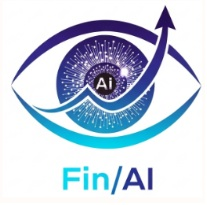